# Misbar - Data Quality & Anomaly Monitoring for E-Commerce Data Warehouses





Data Sourec: Olist Brazilian e-commerce dataset (orders, items, payments, products, customers, sellers) 6 out of 9 (3 were dropped)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')

print('orders', orders.shape)
print('items', items.shape)
print('payments', payments.shape)
print('products', products.shape)
print('customers', customers.shape)
print('sellers', sellers.shape)

orders (99441, 8)
items (112650, 7)
payments (103886, 5)
products (32951, 9)
customers (99441, 5)
sellers (3095, 4)


## 1. Look at the data first: Data Explore

Before doing anything, we want to see how many missing values and duplicates there are and the data types of the features.

In [3]:
def explore(table, df):
    print(f'---{ table} ---')
    print('Info:', df.info())
    print('Shape:', df.shape)
    print('Nulls:\n', df.isnull().sum()[df.isnull().sum() > 0])
    print('Duplicate rows:', df.duplicated().sum())

In [4]:
tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'products': products,
    'customers': customers, 'sellers': sellers
}
for t, df in tables.items():
    explore(t, df)

---orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Info: None
Shape: (99441, 8)
Nulls:
 order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
Duplicate rows: 0
---items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## 2. Cleaning


- drop duplicate rows for each table (there wasnt any duplicated this duplicate drop step is only to show our understanding of the cleaning process )
- change the date columns from text(object) to real dates (datetime)
- fill the missing values (ther was some missing value)

In [6]:
# there wasnt any duplicate
orders = orders.drop_duplicates()
items = items.drop_duplicates()
payments = payments.drop_duplicates()
products = products.drop_duplicates()
customers = customers.drop_duplicates()
sellers = sellers.drop_duplicates()

print('after dropping duplicates:', len(orders), len(items), len(payments),len(products), len(customers), len(sellers))

after dropping duplicates: 99441 112650 103886 32951 99441 3095


In [7]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')

orders.dtypes


,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [8]:
items.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,datetime64[ns]
price,float64
freight_value,float64


In [9]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

size_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for c in size_cols:
    products[c] = products[c].fillna(products[c].median())

product_summary = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']
for c in product_summary:
    products[c] = products[c].fillna(0)

print('missing values left in products:', products.isnull().sum().sum()) # check after fill the missing values

missing values left in products: 0


In [10]:
pay = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    n_payments=('payment_sequential', 'count'),
    payment_type=('payment_type', 'first')
).reset_index()

pay.head()

,order_id,payment_value,payment_installments,n_payments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


# Merge after cleaning

In [11]:
df = items.merge(orders, on='order_id', how='left')
df = df.merge(pay, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(sellers, on='seller_id', how='left')

# some extra columns about the whole order
df['n_items_in_order'] = df.groupby('order_id')['order_item_id'].transform('count')
df['order_price_total'] = df.groupby('order_id')['price'].transform('sum')
df['order_freight_total'] = df.groupby('order_id')['freight_value'].transform('sum')

print('final table:', df.shape)
df.head()

final table: (112650, 36)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,n_items_in_order,order_price_total,order_freight_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,27277,volta redonda,SP,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,3471,sao paulo,SP,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,37564,borda da mata,MG,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,14403,franca,SP,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,87900,loanda,PR,1,199.90,18.14


## EDA

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
order_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "customer_city",
    "customer_state"
]

orders = (
    df[order_columns]
    .drop_duplicates("order_id")
    .copy()
)

items = (
    df[df["order_item_id"].notna()]
    .drop_duplicates(["order_id", "order_item_id"])
    .copy()
)


delivered_order_ids = orders.loc[
    orders["order_status"].eq("delivered"),
    "order_id"
]

sold_items = items[
    items["order_id"].isin(delivered_order_ids)
].copy()

print(f"Orders: {len(orders):,}")
print(f"Order items: {len(items):,}")
print(f"Delivered order items: {len(sold_items):,}")

Orders: 98,666
Order items: 112,650
Delivered order items: 110,197


,payment_type,Number_of_Transactions,Total_Payment,Average_Payment,Transaction_Percentage
1,credit_card,76795,12542084.19,163.319021,73.92
0,boleto,19784,2869361.27,145.034435,19.04
4,voucher,5775,379436.87,65.703354,5.56
2,debit_card,1529,217989.79,142.570170,1.47
3,not_defined,3,0.00,0.000000,0.00


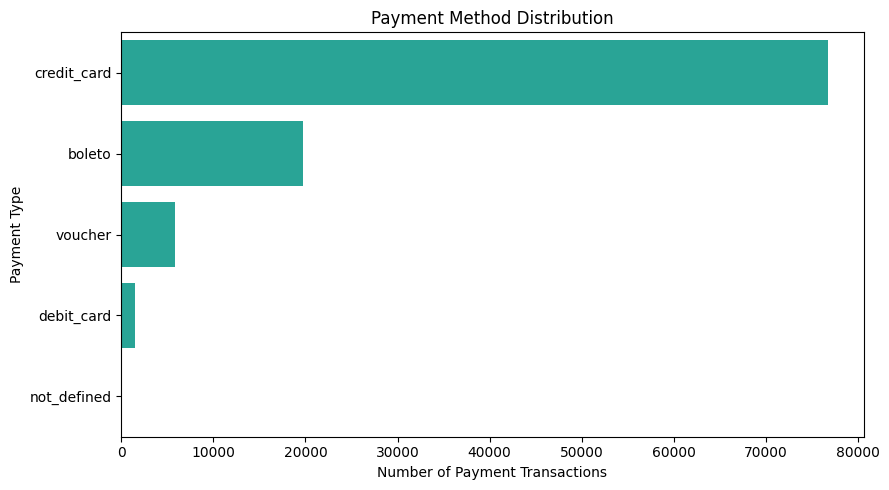

In [14]:
payment_summary = (
    payments.groupby("payment_type", as_index=False)
    .agg(
        Number_of_Transactions=("payment_sequential", "count"),
        Total_Payment=("payment_value", "sum"),
        Average_Payment=("payment_value", "mean")
    )
    .sort_values("Number_of_Transactions", ascending=False)
)

payment_summary["Transaction_Percentage"] = (
    payment_summary["Number_of_Transactions"]
    .div(payment_summary["Number_of_Transactions"].sum())
    .mul(100)
    .round(2)
)

display(payment_summary)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_summary,
    x="Number_of_Transactions",
    y="payment_type",
    color="#14B8A6"
)

plt.title("Payment Method Distribution")
plt.xlabel("Number of Payment Transactions")
plt.ylabel("Payment Type")
plt.tight_layout()
plt.show()

,product_category_name,Units_Sold,Number_of_Orders,Total_Product_Value,Average_Price
13,cama_mesa_banho,10953,9272,1023434.76,93.438762
11,beleza_saude,9465,8647,1233131.72,130.283330
32,esporte_lazer,8431,7530,954852.55,113.254958
54,moveis_decoracao,8160,6307,711927.69,87.246040
44,informatica_acessorios,7644,6530,888724.61,116.264339
73,utilidades_domesticas,6795,5743,615628.69,90.600249
66,relogios_presentes,5859,5495,1166176.98,199.040276
70,telefonia,4430,4093,309860.23,69.945876
40,ferramentas_jardim,4268,3448,470495.28,110.237882
8,automotivo,4140,3810,578966.65,139.847017


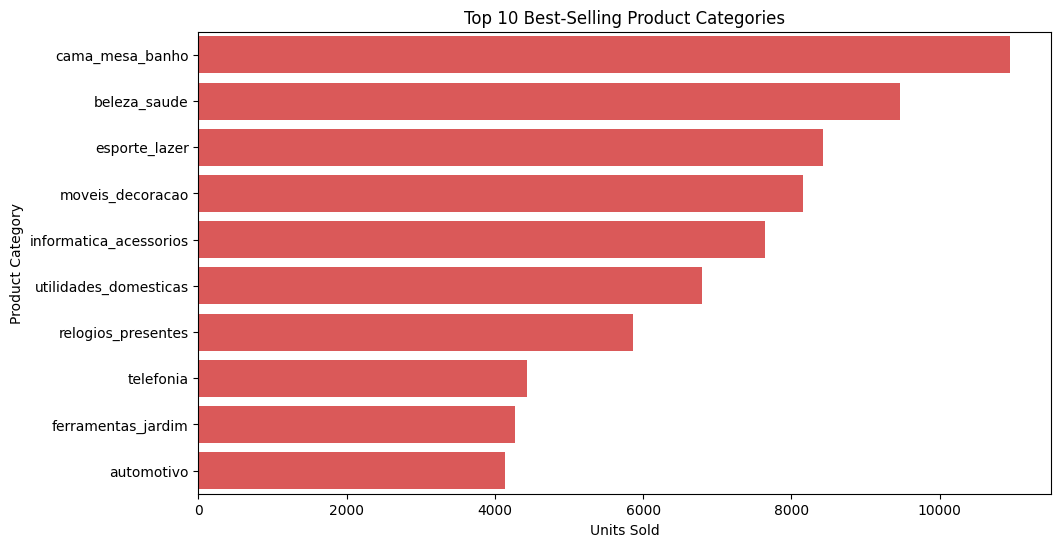

In [15]:
product_summary = (
    sold_items.groupby(
        ["product_category_name"],
        as_index=False,
        dropna=False
    )
    .agg(
        Units_Sold=("order_item_id", "count"),
        Number_of_Orders=("order_id", "nunique"),
        Total_Product_Value=("price", "sum"),
        Average_Price=("price", "mean")
    )
    .sort_values(
        ["Units_Sold", "Total_Product_Value"],
        ascending=[False, False]
    )
)

top_categories = product_summary.head(10).copy()

display(top_categories)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top_categories,
    x="Units_Sold",
    y="product_category_name",
    color="#EF4444"
)

plt.title("Top 10 Best-Selling Product Categories")
plt.xlabel("Units Sold")
plt.ylabel("Product Category")
plt.show()

,Value
Total Orders,9.866600e+04
Unique Customers,9.542000e+04
Unique Products,3.295100e+04
Unique Sellers,3.095000e+03
Delivered Orders,9.647800e+04
Delivered Payment Value,1.542246e+07
Average Delivered Order Value,1.598564e+02


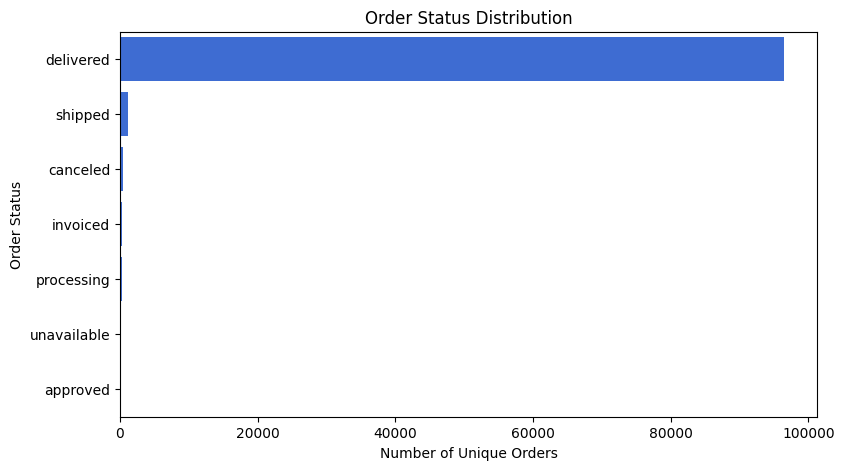

In [16]:
order_payments = (
    payments.groupby("order_id", as_index=False)
    .agg(
        Total_Payment=("payment_value", "sum"),
        Payment_Transactions=("payment_sequential", "count"),
        Maximum_Installments=("payment_installments", "max")
    )
)

orders_analysis = orders.merge(
    order_payments,
    on="order_id",
    how="left",
    validate="one_to_one"
)

delivered_orders = orders_analysis[
    orders_analysis["order_status"].eq("delivered")
].copy()

kpis = pd.Series({
    "Total Orders": orders_analysis["order_id"].nunique(),
    "Unique Customers": orders_analysis["customer_unique_id"].nunique(),
    "Unique Products": items["product_id"].nunique(),
    "Unique Sellers": items["seller_id"].nunique(),
    "Delivered Orders": delivered_orders["order_id"].nunique(),
    "Delivered Payment Value": delivered_orders["Total_Payment"].sum(),
    "Average Delivered Order Value": delivered_orders["Total_Payment"].mean()
})

display(kpis.to_frame("Value"))

status_summary = (
    orders["order_status"]
    .value_counts()
    .rename_axis("Order_Status")
    .reset_index(name="Number_of_Orders")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=status_summary,
    x="Number_of_Orders",
    y="Order_Status",
    color="#2563EB"
)

plt.title("Order Status Distribution")
plt.xlabel("Number of Unique Orders")
plt.ylabel("Order Status")
plt.show()

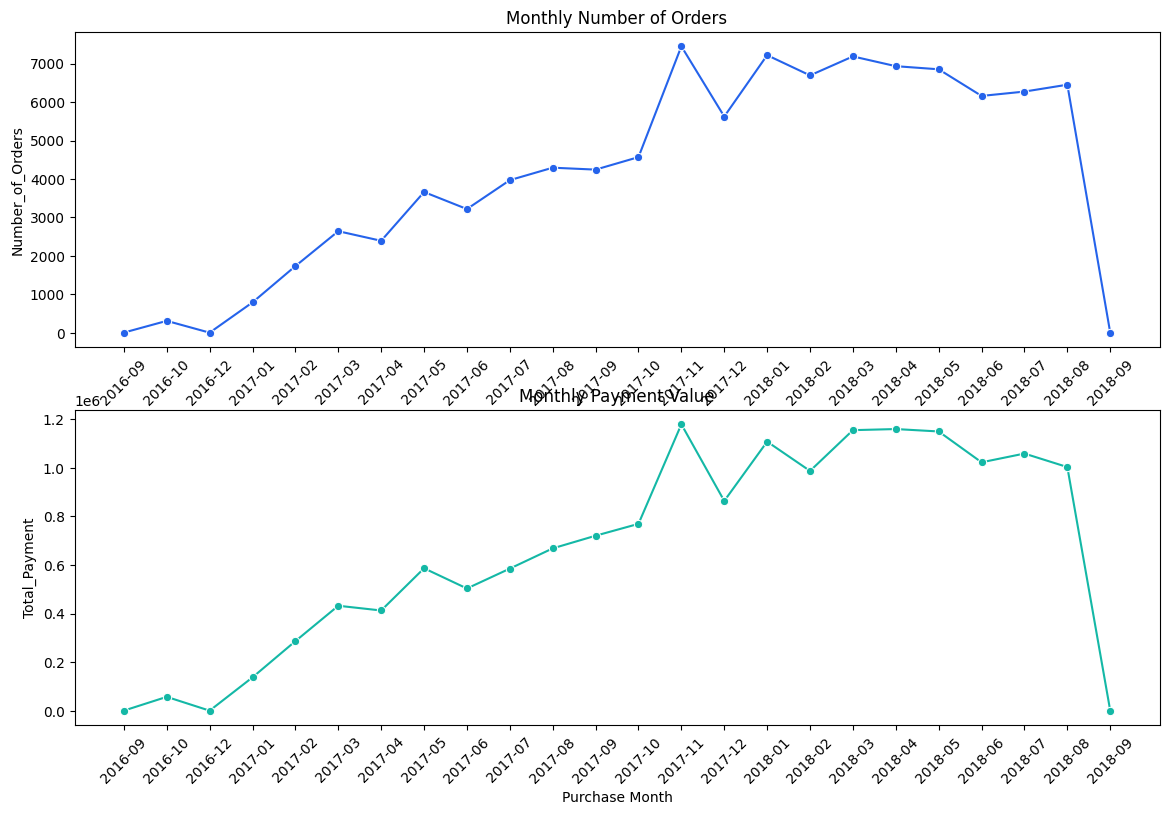

In [17]:
orders_analysis["Purchase_Month"] = (
    orders_analysis["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    orders_analysis.groupby("Purchase_Month", as_index=False)
    .agg(
        Number_of_Orders=("order_id", "nunique"),
        Unique_Customers=("customer_unique_id", "nunique"),
        Total_Payment=("Total_Payment", "sum")
    )
    .sort_values("Purchase_Month")
)


fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.lineplot(
    data=monthly_summary,
    x="Purchase_Month",
    y="Number_of_Orders",
    marker="o",
    color="#2563EB",
    ax=axes[0]
)

axes[0].set_title("Monthly Number of Orders")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=monthly_summary,
    x="Purchase_Month",
    y="Total_Payment",
    marker="o",
    color="#14B8A6",
    ax=axes[1]
)

axes[1].set_title("Monthly Payment Value")
axes[1].set_xlabel("Purchase Month")
axes[1].tick_params(axis="x", rotation=45)


plt.show()

## 4. Keep only the good rows (to build clean basline)


make sure :
- price is not 0 or negative
- freight is not negative
- dates are not in the wrong order (delivered before it was bought, etc.)
- status is  "delivered" but there is no delivery date



In [18]:
good = df.copy()

good = good[good['price'] > 0]
good = good[good['freight_value'] >= 0]
good = good[good['payment_value'] > 0]

purchase = good['order_purchase_timestamp']
delivered = good['order_delivered_customer_date']
carrier = good['order_delivered_carrier_date']
approved = good['order_approved_at']

good = good[~(delivered < purchase).fillna(False)]
good = good[~(carrier < purchase).fillna(False)]
good = good[~(approved < purchase).fillna(False)]
good = good[~(delivered < carrier).fillna(False)]
good = good[~((good['order_status'] == 'delivered') & delivered.isna()).fillna(False)]

print('rows left after the rules:', len(good),' ',len(df) - len(good),'were dropped du to error in rules')

rows left after the rules: 112402   248 were dropped du to error in rules


In [19]:
for c in ['price', 'freight_value', 'payment_value', 'product_weight_g']:
    cut = good[c].quantile(0.999)
    good = good[good[c] <= cut]

good = good.reset_index(drop=True)

print('clean baseline:', len(good), 'rows')
good[['price', 'freight_value', 'payment_value', 'product_weight_g']].describe()

clean baseline: 112075 rows


,price,freight_value,payment_value,product_weight_g
count,112075.000000,112075.000000,112075.000000,112075.000000
mean,116.926320,19.708990,173.097283,2062.316110
std,157.162946,14.001544,207.063611,3659.479914
min,0.850000,0.000000,9.590000,0.000000
25%,39.900000,13.070000,65.480000,300.000000
50%,74.900000,16.250000,114.110000,700.000000
75%,133.900000,21.150000,194.255000,1800.000000
max,2110.000000,171.500000,2234.660000,30000.000000


## 5. Add errors  to test the models


- **label = 0** -> normal row
- **label = 1** -> row with a data quality problem

3 kinds of errors:

| type | what it is | examples |
|---|---|---|
| simple | value is obviously wrong | negative price, price = 0, negative freight, missing date |
| moderate | value is possible but way too big | price or weight multiplied by 5 to 15 |
| complex | one value alone looks fine, but two columns don't agree | delivered before it was bought, payment doesn't match the total |

Each row gets **only one** error

In [20]:
data = good.copy()
data['label'] = 0
data['error_type'] = 'none'

n = len(data)
shuffled = np.random.permutation(n)

simple_rows = shuffled[:int(0.05 * n)]
moderate_rows = shuffled[int(0.05 * n):int(0.09 * n)]
complex_rows = shuffled[int(0.09 * n):int(0.14 * n)]

print('simple:', len(simple_rows))
print('moderate:', len(moderate_rows))
print('complex:', len(complex_rows))

simple: 5603
moderate: 4483
complex: 5604


In [21]:

def split_rows(rows, k):
    return np.array_split(np.random.permutation(rows), k)

In [22]:
#simple errors
p1, p2, p3, p4, p5 = split_rows(simple_rows, 5)

data.loc[p1, 'price'] = -data.loc[p1, 'price']
data.loc[p1, 'error_type'] = 'negative_price'

data.loc[p2, 'price'] = 0
data.loc[p2, 'error_type'] = 'zero_price'

data.loc[p3, 'freight_value'] = -data.loc[p3, 'freight_value'] - 1
data.loc[p3, 'error_type'] = 'negative_freight'

data.loc[p4, 'payment_value'] = -data.loc[p4, 'payment_value']
data.loc[p4, 'error_type'] = 'negative_payment'

# a broken date string becomes NaT after pd.to_datetime, so we just put NaT
data.loc[p5, 'order_approved_at'] = pd.NaT
data.loc[p5, 'shipping_limit_date'] = pd.NaT
data.loc[p5, 'error_type'] = 'broken_date'

data.loc[simple_rows, 'label'] = 1
print('simple errors done')

simple errors done


In [23]:
# moderate errors (values that are too big)
m1, m2, m3 = split_rows(moderate_rows, 3)

data.loc[m1, 'price'] = data.loc[m1, 'price'] * np.random.uniform(5, 15, len(m1))
data.loc[m1, 'error_type'] = 'price_outlier'

data.loc[m2, 'freight_value'] = data.loc[m2, 'freight_value'] * np.random.uniform(5, 15, len(m2))
data.loc[m2, 'error_type'] = 'freight_outlier'

data.loc[m3, 'product_weight_g'] = data.loc[m3, 'product_weight_g'] * np.random.uniform(5, 15, len(m3))
data.loc[m3, 'error_type'] = 'weight_outlier'

data.loc[moderate_rows, 'label'] = 1
print('moderate errors done')

moderate errors done


In [24]:
# complex errors (columns that don't agree)
c1, c2, c3, c4 = split_rows(complex_rows, 4)

data.loc[c1, 'order_delivered_customer_date'] = (
    data.loc[c1, 'order_purchase_timestamp'] - pd.Timedelta(days=5))
data.loc[c1, 'error_type'] = 'delivered_before_purchase'

data.loc[c2, 'order_approved_at'] = (
    data.loc[c2, 'order_purchase_timestamp'] - pd.Timedelta(days=2))
data.loc[c2, 'error_type'] = 'approved_before_purchase'

data.loc[c3, 'order_delivered_customer_date'] = pd.NaT
data.loc[c3, 'order_status'] = 'delivered'
data.loc[c3, 'error_type'] = 'delivered_no_date'

data.loc[c4, 'payment_value'] = data.loc[c4, 'payment_value'] * np.random.uniform(2, 5, len(c4))
data.loc[c4, 'error_type'] = 'payment_mismatch'

data.loc[complex_rows, 'label'] = 1
print('complex errors done')

complex errors done


In [25]:
print(data['label'].value_counts())
print()
print('percent of bad rows:', round(100 * data['label'].mean(), 2), '%')
print()
print(data[data['label'] == 1]['error_type'].value_counts())

label
0    96385
1    15690
Name: count, dtype: int64

percent of bad rows: 14.0 %

error_type
price_outlier                1495
freight_outlier              1494
weight_outlier               1494
approved_before_purchase     1401
payment_mismatch             1401
delivered_before_purchase    1401
delivered_no_date            1401
negative_freight             1121
negative_price               1121
zero_price                   1121
broken_date                  1120
negative_payment             1120
Name: count, dtype: int64


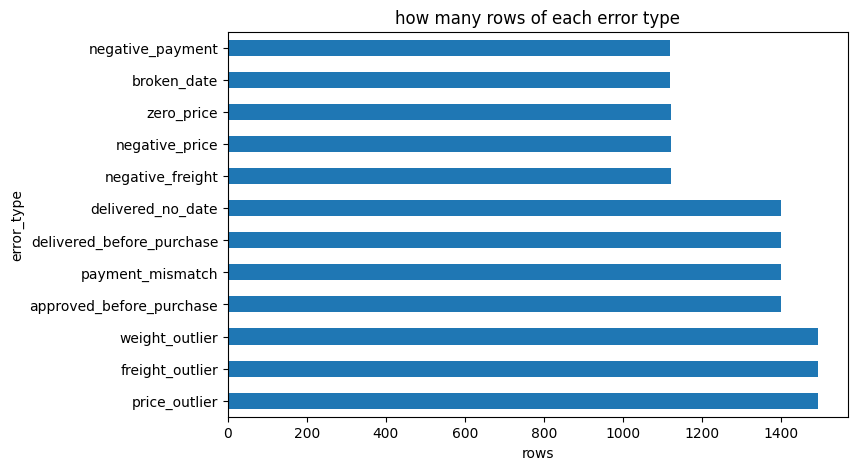

In [26]:
data['error_type'].value_counts().drop('none').plot(kind='barh', figsize=(8, 5))
plt.title('how many rows of each error type')
plt.xlabel('rows')
plt.show()

## 6. features enginering



In [27]:
df2 = data.copy()

# days / hours between the dates
df2['approval_hours'] = (df2['order_approved_at'] - df2['order_purchase_timestamp']).dt.total_seconds() / 3600
df2['delivery_days'] = (df2['order_delivered_customer_date'] - df2['order_purchase_timestamp']).dt.days
df2['carrier_days'] = (df2['order_delivered_carrier_date'] - df2['order_purchase_timestamp']).dt.days
df2['estimated_days'] = (df2['order_estimated_delivery_date'] - df2['order_purchase_timestamp']).dt.days
df2['late_days'] = (df2['order_delivered_customer_date'] - df2['order_estimated_delivery_date']).dt.days
df2['shipping_limit_days'] = (df2['shipping_limit_date'] - df2['order_purchase_timestamp']).dt.days
df2['carrier_to_customer_days'] = (df2['order_delivered_customer_date'] - df2['order_delivered_carrier_date']).dt.days

df2[['delivery_days', 'approval_hours', 'late_days']].describe()

,delivery_days,approval_hours,late_days
count,108309.000000,110940.000000,108309.000000
mean,11.783425,9.826215,-12.245197
std,9.573992,23.167472,10.322670
min,-5.000000,-48.000000,-147.000000
25%,6.000000,0.213333,-17.000000
50%,10.000000,0.343333,-13.000000
75%,15.000000,14.762847,-7.000000
max,209.000000,1450.866389,188.000000


In [28]:
# ratios and other useful columns
df2['freight_ratio'] = df2['freight_value'] / df2['price'].replace(0, np.nan)
df2['expected_total'] = df2['order_price_total'] + df2['order_freight_total']
df2['payment_diff'] = df2['payment_value'] - df2['expected_total']
df2['payment_ratio'] = df2['payment_value'] / df2['expected_total'].replace(0, np.nan)
df2['volume'] = df2['product_length_cm'] * df2['product_height_cm'] * df2['product_width_cm']
df2['price_per_gram'] = df2['price'] / df2['product_weight_g'].replace(0, np.nan)
df2['n_missing'] = df2.isnull().sum(axis=1)
df2['is_delivered'] = (df2['order_status'] == 'delivered').astype(int)
df2['has_delivery_date'] = df2['order_delivered_customer_date'].notna().astype(int)

# time of the purchase
df2['purchase_hour'] = df2['order_purchase_timestamp'].dt.hour
df2['purchase_month'] = df2['order_purchase_timestamp'].dt.month
df2['purchase_dayofweek'] = df2['order_purchase_timestamp'].dt.dayofweek

print('columns now:', df2.shape[1])

columns now: 57


In [29]:
# drop the ids, the city columns (too many different values) and the raw dates
drop_cols = ['order_id', 'customer_id', 'customer_unique_id', 'product_id', 'seller_id',
             'customer_city', 'seller_city', 'customer_zip_code_prefix',
             'seller_zip_code_prefix', 'error_type'] + date_cols + ['shipping_limit_date']

df2 = df2.drop(columns=drop_cols)

# text columns -> numbers
df2 = pd.get_dummies(df2, columns=['order_status', 'payment_type'], dummy_na=True)
for c in ['product_category_name', 'customer_state', 'seller_state']:
    df2[c] = df2[c].astype('category').cat.codes

X = df2.drop(columns=['label']).astype(float).fillna(-1)
y = df2['label']

print('X:', X.shape)
print('y:', y.shape)
X.head()

X: (112075, 51)
y: (112075,)


,order_item_id,price,freight_value,payment_value,payment_installments,n_payments,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,...,order_status_invoiced,order_status_processing,order_status_shipped,order_status_unavailable,order_status_nan,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher,payment_type_nan
0,1.0,58.90,13.29,72.19,2.0,1.0,26.0,58.0,598.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,239.90,19.93,259.83,3.0,1.0,63.0,56.0,239.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,199.00,17.87,216.87,5.0,1.0,54.0,59.0,695.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,12.99,12.79,25.78,2.0,1.0,62.0,42.0,480.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,199.90,18.14,218.04,3.0,1.0,40.0,59.0,409.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 7. Train / validation / test split

70% train, 15% validation, 15% test.

We use `stratify=y` so the percentage of bad rows is the same in all three parts.
The validation part is used to choose the threshold of the autoencoder, and the test part
is only used at the very end.

In [30]:
from sklearn.model_selection import train_test_split

# First, we took out the test part
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# then split what is left into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print('train:', X_train.shape, ' bad rows:', round(100 * y_train.mean(), 2), '%')
print('val:  ', X_val.shape, ' bad rows:', round(100 * y_val.mean(), 2), '%')
print('test: ', X_test.shape, ' bad rows:', round(100 * y_test.mean(), 2), '%')

train: (78449, 51)  bad rows: 14.0 %
val:   (16814, 51)  bad rows: 14.0 %
test:  (16812, 51)  bad rows: 14.0 %


In [31]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

# We saved the scores here so we can compare the 3 models at the end
results = {}

def show_results(name, y_true, y_pred):
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    results[name] = {'precision': round(p, 4), 'recall': round(r, 4), 'f1': round(f, 4)}

    print(name)
    print('precision:', round(p, 4))
    print('recall:   ', round(r, 4))
    print('f1:       ', round(f, 4))
    print()
    print(classification_report(y_true, y_pred, digits=4))
    print('confusion matrix:')
    print(confusion_matrix(y_true, y_pred))

## Model 1: Random Forest


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,
                            class_weight='balanced',
                            random_state=42,
                            n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
show_results('Random Forest', y_test, rf_pred)

Random Forest
precision: 0.9941
recall:    0.9286
f1:        0.9602

              precision    recall  f1-score   support

           0     0.9885    0.9991    0.9938     14458
           1     0.9941    0.9286    0.9602      2354

    accuracy                         0.9892     16812
   macro avg     0.9913    0.9639    0.9770     16812
weighted avg     0.9893    0.9892    0.9891     16812

confusion matrix:
[[14445    13]
 [  168  2186]]


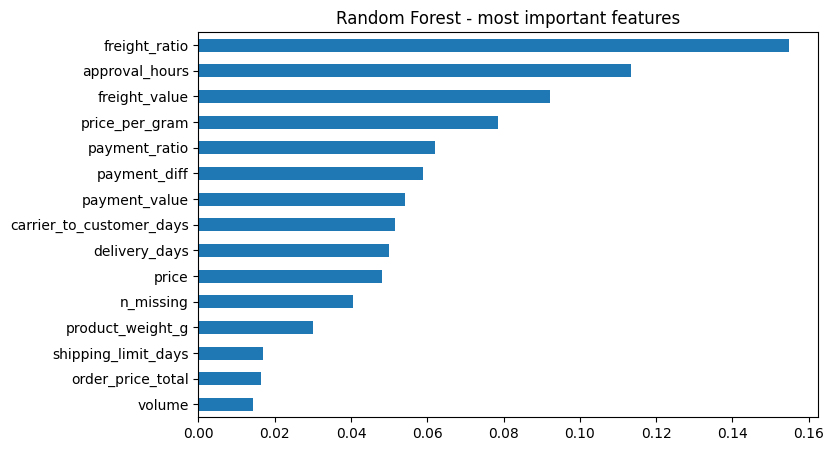

In [33]:
# which columns does the model use the most?
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15).plot(kind='barh', figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title('Random Forest - most important features')
plt.show()

## Model 2: XGBoost



In [34]:
from xgboost import XGBClassifier

# how many normal rows for each bad row
weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight =', round(weight, 2))

xgb = XGBClassifier(n_estimators=300,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    scale_pos_weight=weight,
                    eval_metric='logloss',
                    random_state=42,
                    n_jobs=-1)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
show_results('XGBoost', y_test, xgb_pred)

scale_pos_weight = 6.14
XGBoost
precision: 0.9785
recall:    0.9669
f1:        0.9726

              precision    recall  f1-score   support

           0     0.9946    0.9965    0.9956     14458
           1     0.9785    0.9669    0.9726      2354

    accuracy                         0.9924     16812
   macro avg     0.9866    0.9817    0.9841     16812
weighted avg     0.9924    0.9924    0.9924     16812

confusion matrix:
[[14408    50]
 [   78  2276]]


## Model 3: Autoencoder

This one is different. It is **not** trained on the labels.

The autoencoder is a neural network that learns to copy its input. we train it **only on
the normal rows**, so it becomes good at rebuilding normal rows. When we give it a bad row
it cannot rebuild it well, so the error is big. Big error = probably a bad row.

The advantage is that it can find errors we never showed it before.

Two things we had to do:
- **scale the data** first, because neural networks don't like columns with very different
  sizes (price is ~100, weight is ~2000)
- only give it the **numeric columns**. We tried with all the columns including the
  one-hot ones and the result was much worse (f1 went from about 0.86 down to 0.61).
  The one-hot columns are basically noise for the autoencoder and they hide the real error.

In [35]:
from sklearn.preprocessing import StandardScaler

# only the numeric columns for the autoencoder
ae_cols = ['price', 'freight_value', 'payment_value', 'payment_installments', 'n_payments',
           'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
           'order_price_total', 'order_freight_total', 'n_items_in_order', 'expected_total',
           'approval_hours', 'delivery_days', 'carrier_days', 'estimated_days', 'late_days',
           'shipping_limit_days', 'carrier_to_customer_days', 'freight_ratio', 'payment_diff',
           'payment_ratio', 'volume', 'price_per_gram', 'n_missing', 'is_delivered',
           'has_delivery_date']

scaler = StandardScaler()
X_train_ae = scaler.fit_transform(X_train[ae_cols])
X_val_ae = scaler.transform(X_val[ae_cols])
X_test_ae = scaler.transform(X_test[ae_cols])

# cut the very extreme scaled values, otherwise one row can dominate the whole error
X_train_ae = np.clip(X_train_ae, -10, 10)
X_val_ae = np.clip(X_val_ae, -10, 10)
X_test_ae = np.clip(X_test_ae, -10, 10)

# train only on the normal rows
X_train_normal = X_train_ae[y_train.values == 0]

print('autoencoder input:', X_train_ae.shape[1], 'columns')
print('training on', len(X_train_normal), 'normal rows')

autoencoder input: 28 columns
training on 67467 normal rows


In [36]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

n_features = X_train_ae.shape[1]

ae = keras.Sequential([
    keras.layers.Input(shape=(n_features,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),   # the small middle layer
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(n_features)
])

ae.compile(optimizer='adam', loss='mse')
ae.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,940 (34.92 KB)

 Trainable params: 8,940 (34.92 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = ae.fit(X_train_normal, X_train_normal,
                 epochs=30,
                 batch_size=256,
                 validation_split=0.1,
                 verbose=1)

Epoch 1/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2641 - val_loss: 0.0769
Epoch 2/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0483 - val_loss: 0.0324
Epoch 3/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0263 - val_loss: 0.0226
Epoch 4/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0197 - val_loss: 0.0181
Epoch 5/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0153 - val_loss: 0.0144
Epoch 6/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0118 - val_loss: 0.0117
Epoch 7/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0097 - val_loss: 0.0104
Epoch 8/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083 - val_loss: 0.0089
Epoch 9/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0073 - val_loss: 0.0079
Epoch 10/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0065 - val_loss: 0.0069
Epoch 11/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 12/30
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

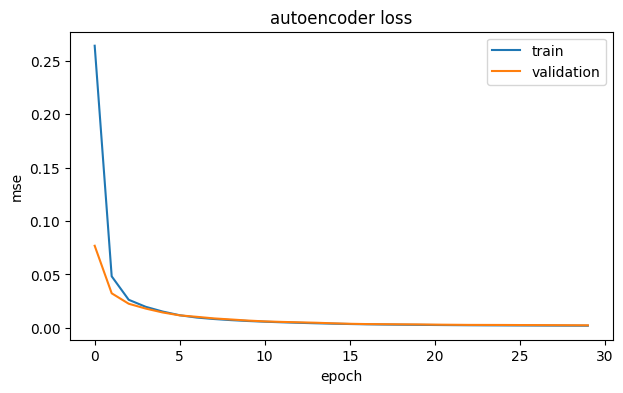

In [38]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('autoencoder loss')
plt.xlabel('epoch')
plt.ylabel('mse')
plt.legend()
plt.show()

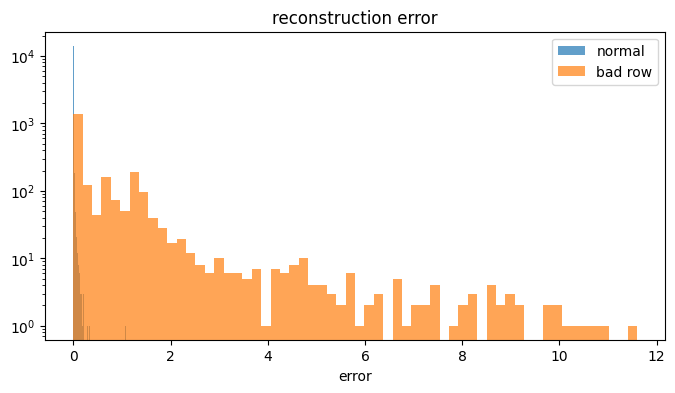

In [39]:
# reconstruction error = how wrong the copy is
val_pred = ae.predict(X_val_ae, verbose=0)
test_pred = ae.predict(X_test_ae, verbose=0)

val_error = np.mean((X_val_ae - val_pred) ** 2, axis=1)
test_error = np.mean((X_test_ae - test_pred) ** 2, axis=1)

plt.figure(figsize=(8, 4))
plt.hist(test_error[y_test.values == 0], bins=60, alpha=0.7, label='normal', log=True)
plt.hist(test_error[y_test.values == 1], bins=60, alpha=0.7, label='bad row', log=True)
plt.title('reconstruction error')
plt.xlabel('error')
plt.legend()
plt.show()

In [40]:
# find the best threshold on the VALIDATION set (not on the test set!)
best_f1 = 0
best_threshold = 0

for q in np.arange(0.70, 0.995, 0.005):
    t = np.quantile(val_error, q)
    f = f1_score(y_val, (val_error > t).astype(int), zero_division=0)
    if f > best_f1:
        best_f1 = f
        best_threshold = t

print('best threshold:', round(best_threshold, 4))
print('f1 on validation:', round(best_f1, 4))

best threshold: 0.0166
f1 on validation: 0.8279


In [41]:
ae_pred = (test_error > best_threshold).astype(int)
show_results('Autoencoder', y_test, ae_pred)

Autoencoder
precision: 0.8548
recall:    0.8076
f1:        0.8305

              precision    recall  f1-score   support

           0     0.9689    0.9777    0.9733     14458
           1     0.8548    0.8076    0.8305      2354

    accuracy                         0.9538     16812
   macro avg     0.9119    0.8926    0.9019     16812
weighted avg     0.9530    0.9538    0.9533     16812

confusion matrix:
[[14135   323]
 [  453  1901]]


## Compare the 3 models

In [42]:
comparison = pd.DataFrame(results).T
comparison

,precision,recall,f1
Random Forest,0.9941,0.9286,0.9602
XGBoost,0.9785,0.9669,0.9726
Autoencoder,0.8548,0.8076,0.8305


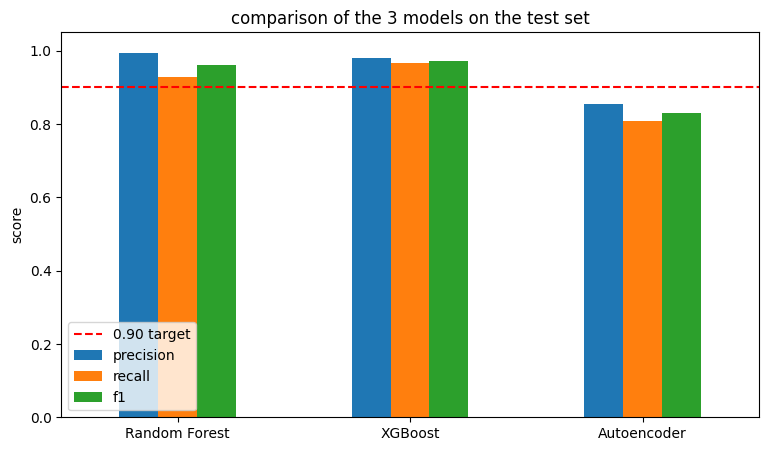

In [43]:
comparison.plot(kind='bar', figsize=(9, 5), rot=0)
plt.axhline(0.9, color='red', linestyle='--', label='0.90 target')
plt.title('comparison of the 3 models on the test set')
plt.ylabel('score')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## Combine the 3 models

Instead of picking one model, we will use all three together.

Each model gives a score between 0 and 1 (Random Forest and XGBoost already give a
probability, and for the autoencoder, we will divide the reconstruction error by a big value so it
is also between 0 and 1). Then we will take the **average of the three scores**.


In [44]:
# all three scores between 0 and 1
rf_val_score = rf.predict_proba(X_val)[:, 1]
rf_test_score = rf.predict_proba(X_test)[:, 1]

xgb_val_score = xgb.predict_proba(X_val)[:, 1]
xgb_test_score = xgb.predict_proba(X_test)[:, 1]

# The autoencoder error is not between 0 and 1, so  we scale it
ae_max = np.quantile(val_error, 0.999)
ae_val_score = np.clip(val_error / ae_max, 0, 1)
ae_test_score = np.clip(test_error / ae_max, 0, 1)

# average of the 3
combined_val = (rf_val_score + xgb_val_score + ae_val_score) / 3
combined_test = (rf_test_score + xgb_test_score + ae_test_score) / 3

# best threshold on the validation set
best_f1_c = 0
best_threshold_c = 0
for t in np.arange(0.05, 0.96, 0.01):
    f = f1_score(y_val, (combined_val > t).astype(int), zero_division=0)
    if f > best_f1_c:
        best_f1_c = f
        best_threshold_c = t

print('best threshold:', round(best_threshold_c, 2))
print('f1 on validation:', round(best_f1_c, 4))
print()

combined_pred = (combined_test > best_threshold_c).astype(int)
show_results('Combined (3 models)', y_test, combined_pred)

best threshold: 0.31
f1 on validation: 0.9777

Combined (3 models)
precision: 0.9856
recall:    0.9613
f1:        0.9733

              precision    recall  f1-score   support

           0     0.9937    0.9977    0.9957     14458
           1     0.9856    0.9613    0.9733      2354

    accuracy                         0.9926     16812
   macro avg     0.9897    0.9795    0.9845     16812
weighted avg     0.9926    0.9926    0.9926     16812

confusion matrix:
[[14425    33]
 [   91  2263]]


                     precision  recall      f1
Random Forest           0.9941  0.9286  0.9602
XGBoost                 0.9785  0.9669  0.9726
Autoencoder             0.8548  0.8076  0.8305
Combined (3 models)     0.9856  0.9613  0.9733


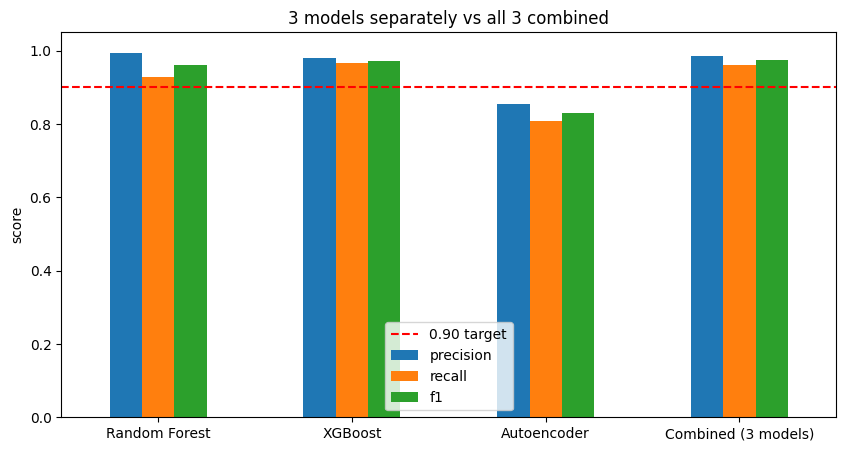

In [45]:
comparison = pd.DataFrame(results).T
print(comparison)

comparison.plot(kind='bar', figsize=(10, 5), rot=0)
plt.axhline(0.9, color='red', linestyle='--', label='0.90 target')
plt.title('3 models separately vs all 3 combined')
plt.ylabel('score')
plt.ylim(0, 1.05)
plt.legend()
plt.show()

## SHAP - why was this row flagged?

The models tell us a row is bad, but not **why**. For a data quality tool that is not
enough: the person who has to fix the row needs to know which column is the problem.

SHAP gives every column a value for one single row:
- positive value -> this column pushed the score **up** (more suspicious)
- negative value -> this column pushed the score **down** (more normal)

SHAP works on tree models, so we use it on XGBoost. XGBoost is one third of the combined
score, and it agrees with Random Forest on almost every row, so its explanation is a good
explanation for the combination too. The autoencoder is a neural network and TreeExplainer
does not work on it, so for that part we just look at which column it failed the most to
rebuild.

shap values shape: (500, 51)


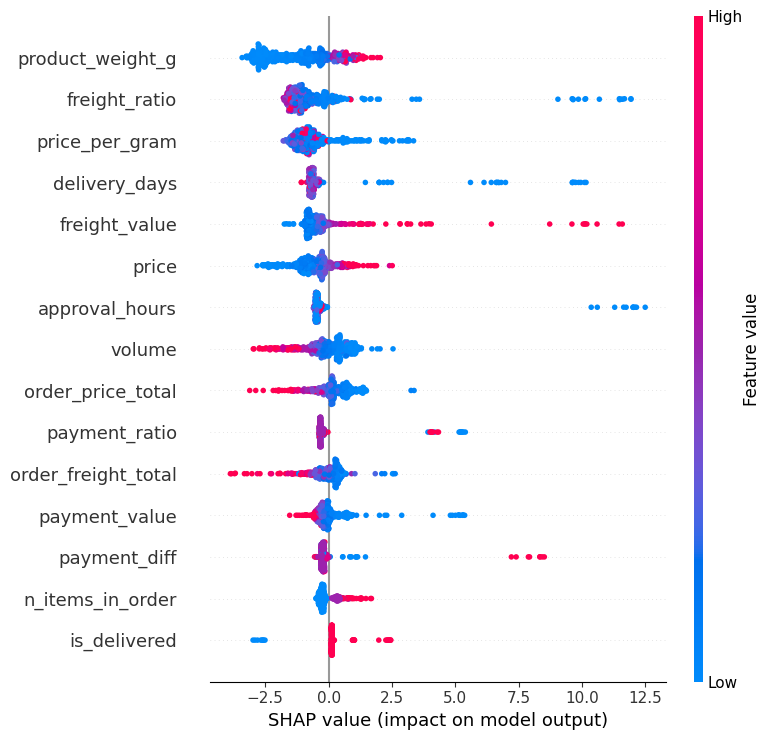

In [46]:
import shap

# SHAP is slow on 16000 rows, so we take a sample of the test set
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# with some versions shap returns a list (one array per class), we keep class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print('shap values shape:', np.array(shap_values).shape)

shap.summary_plot(shap_values, X_sample, max_display=15)

In [47]:
# scores and autoencoder errors with the same index, so we can look up one row
combined_score = pd.Series(combined_test, index=X_test.index)
ae_error_by_column = pd.DataFrame((X_test_ae - test_pred) ** 2,
                                  index=X_test.index, columns=ae_cols)

def explain_record(row_id):
    i = list(X_sample.index).index(row_id)
    contrib = pd.Series(shap_values[i], index=X_sample.columns)
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5)

    print('=' * 60)
    print('record', row_id)
    print('combined score:', round(combined_score[row_id], 3),
          '-> flagged' if combined_score[row_id] > best_threshold_c else '-> not flagged')
    print('real error that we injected:', data.loc[row_id, 'error_type'])
    print()
    print('top reasons from SHAP:')
    for col, val in top.items():
        direction = 'suspicious' if val > 0 else 'normal'
        print(f'  {col:<26} shap={val:+.3f}  value={X_sample.loc[row_id, col]:.2f}  ({direction})')
    worst = ae_error_by_column.loc[row_id].sort_values(ascending=False).index[0]
    print()
    print('column the autoencoder could not rebuild:', worst)
    print()

# one flagged record of each kind
flagged = [i for i in X_sample.index if combined_score[i] > best_threshold_c]
shown = []
for i in flagged:
    e = data.loc[i, 'error_type']
    if e not in shown and e != 'none':
        explain_record(i)
        shown.append(e)
    if len(shown) == 3:
        break

record 36938
combined score: 0.671 -> flagged
real error that we injected: zero_price

top reasons from SHAP:
  freight_ratio              shap=+9.647  value=-1.00  (suspicious)
  price_per_gram             shap=+2.197  value=0.00  (suspicious)
  product_weight_g           shap=-1.032  value=650.00  (normal)
  price                      shap=-0.974  value=0.00  (normal)
  volume                     shap=+0.747  value=600.00  (suspicious)

column the autoencoder could not rebuild: freight_ratio

record 38341
combined score: 0.608 -> flagged
real error that we injected: negative_payment

top reasons from SHAP:
  payment_value              shap=+5.294  value=-199.00  (suspicious)
  payment_ratio              shap=+3.917  value=-1.00  (suspicious)
  product_weight_g           shap=-1.657  value=342.00  (normal)
  order_freight_total        shap=-1.179  value=0.00  (normal)
  freight_value              shap=-1.073  value=0.00  (normal)

column the autoencoder could not rebuild: payment_rati

record 36938 - real error: zero_price


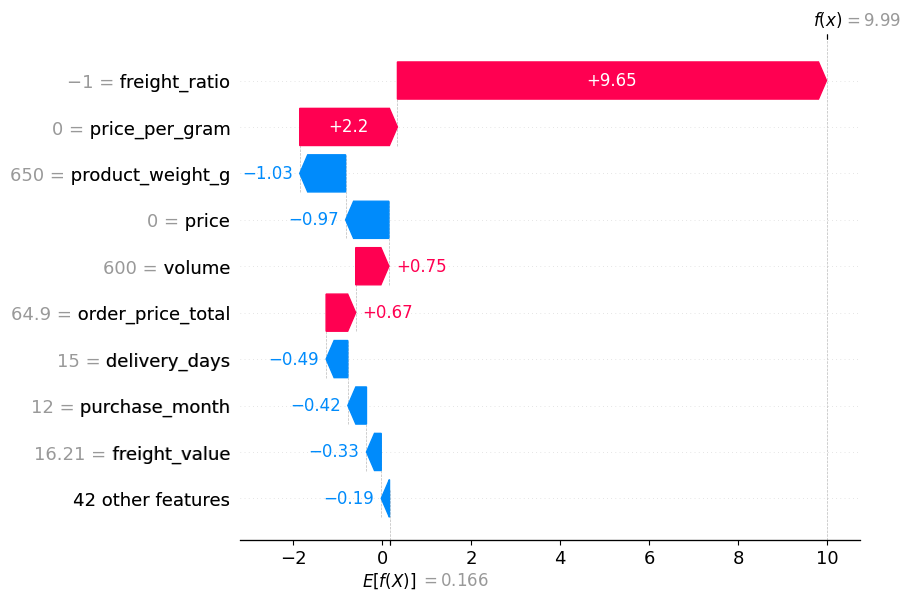

In [48]:
#  the same thing as a plot, for one row
row_id = flagged[0]
i = list(X_sample.index).index(row_id)

# with some versions expected_value is a list of 2 numbers instead of one
base = explainer.expected_value
if hasattr(base, '__len__'):
    base = base[-1]

one = shap.Explanation(values=shap_values[i],
                       base_values=base,
                       data=X_sample.iloc[i].values,
                       feature_names=list(X_sample.columns))

print('record', row_id, '- real error:', data.loc[row_id, 'error_type'])
shap.plots.waterfall(one, max_display=10)

**Check the explanation against the truth.** In the output above, compare the top SHAP
feature with the line `real error that we injected`. For a `payment_mismatch` row we expect
`payment_diff` or `payment_ratio` at the top, for a `zero_price` row we expect `price` or
`freight_ratio`, for a `freight_outlier` row we expect `freight_value` or `freight_ratio`.
If they match it means the model is really using the right column and not guessing.

This is what makes the tool usable. Instead of only saying *"this row is suspicious"*, the
alert can say *"this row is suspicious because the payment does not match the order
total"*, and the person can go and fix exactly that column.

## Which errors are hard to find?

Here we check every error type separately, to see where the models fail.

In [49]:
error_test = data.loc[X_test.index, 'error_type']

breakdown = pd.DataFrame({'n_rows': error_test.value_counts()})
for name, pred in [('RandomForest', rf_pred), ('XGBoost', xgb_pred), ('Autoencoder', ae_pred)]:
    found = pd.Series(pred, index=X_test.index).groupby(error_test).mean()
    breakdown[name] = found.round(3)

breakdown = breakdown.sort_values('RandomForest')
breakdown

,n_rows,RandomForest,XGBoost,Autoencoder
error_type,,,,
none,14458,0.001,0.003,0.022
weight_outlier,222,0.383,0.685,0.171
freight_outlier,235,0.928,0.987,0.970
price_outlier,208,0.938,0.981,0.803
payment_mismatch,193,0.995,1.000,1.000
delivered_no_date,226,1.000,1.000,1.000
approved_before_purchase,212,1.000,1.000,1.000
delivered_before_purchase,207,1.000,1.000,0.135
zero_price,180,1.000,1.000,1.000


## Conclusion

**Results (test set):**

| model | precision | recall | f1 |
|---|---|---|---|
| Random Forest | 0.9941 | 0.9286 | 0.9602 |
| XGBoost | 0.9785 | 0.9669 | 0.9726 |
| Autoencoder | 0.8548 | 0.8076 | 0.8305 |
| **Combined (3 models)** | **0.9856** | **0.9613** | **0.9733** |

(the Autoencoder numbers can change a little every run because of TensorFlow randomness)

**What we learned:**

1. **XGBoost was the best model**, Random Forest was very close. Both pass the 0.90 target
   for precision, recall and f1.

2. **The autoencoder is weaker than the other two**, which makes sense: it never sees the
   labels, it only knows what a normal row looks like. But it is still useful, because it
   can find an error type that was never in the training data - the other two models can't
   do that.

3. **The hardest error is `weight_outlier`.** All three models miss a lot of them. The
   reason is that product weights are already very different in the real data (from a few
   grams to many kilos), so a weight multiplied by 5 still looks possible. The other
   errors, like a negative price or a delivery before the purchase, are impossible values,
   so they are easy to find.

4. **The new features we created matter more than the original columns.** In the
   feature importance plot the top features are the date differences and the payment ratio.
   Without them the complex errors would be invisible, because in those rows every single
   column looks fine on its own.

**What could be improved:**

- the errors are fake, we added them ourselves. Real errors in a real warehouse are probably
  messier, and the scores would be lower

- the autoencoder could probably be better with more epochs or a different size